
MODEL ACCURACY RESULTS

Linear Regression
R2 Score: 0.97
----------------------------------------
Decision Tree
R2 Score: 0.344
----------------------------------------
Random Forest
R2 Score: 0.741
----------------------------------------
Gradient Boosting
R2 Score: 0.87
----------------------------------------
SVR
R2 Score: 0.019
----------------------------------------

BEST MODEL: Linear Regression

TOP IMPORTANT FEATURES

                    Feature  Importance
21          Endurance_Score    0.141744
11       Mental_Focus_Level    0.131931
20              Speed_Score    0.103279
18           Recovery_Score    0.096474
13         Motivation_Level    0.092048
8                   VO2_Max    0.073732
14      Body_Fat_Percentage    0.054881
4   Training_Hours_Per_Week    0.052195
22        Flexibility_Score    0.045116
12             Stress_Level    0.029413
5        Training_Intensity    0.025883
23         Experience_Years    0.022971
15              Muscle_Mass    0.017670
17      

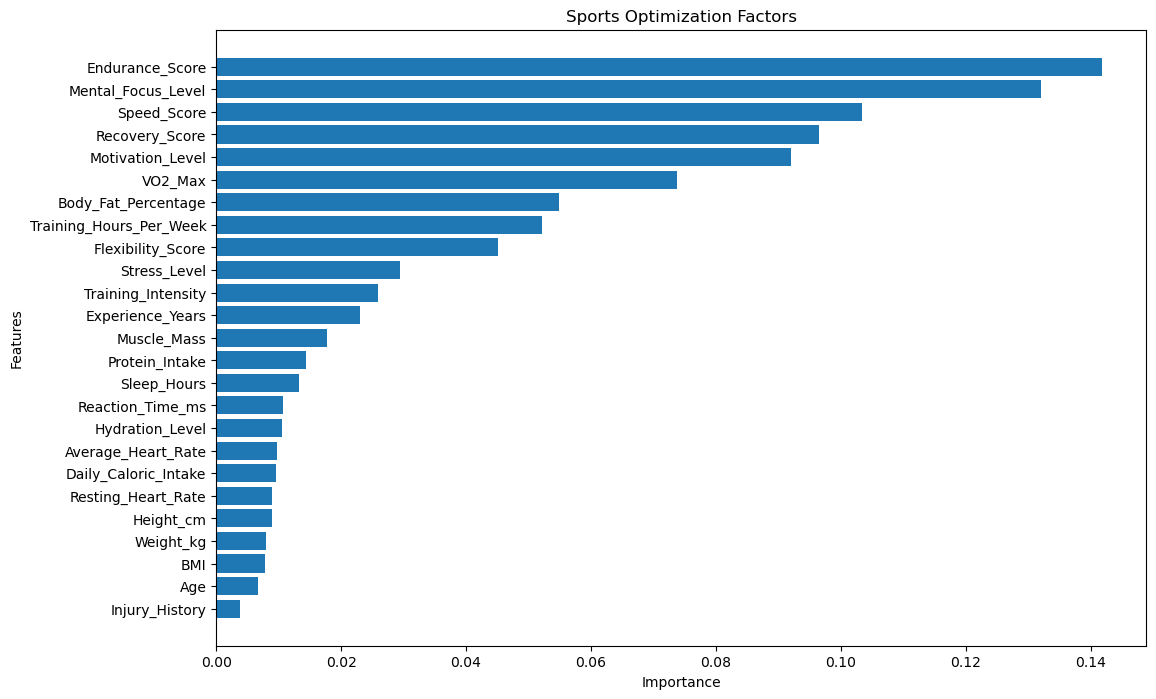


AI SPORTS RECOMMENDATIONS

✔ Reduce stress levels
✔ Improve recovery sessions
✔ Reduce body fat percentage

AI analysis completed successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

data = pd.read_excel(
    "5000 dataset.xlsx"
)

if "Athlete_ID" in data.columns:
    data = data.drop("Athlete_ID", axis=1)

target = "Performance_Metric"

X = data.drop(target, axis=1)

y = data[target]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(),

    "SVR": SVR()

}

print("\nMODEL ACCURACY RESULTS\n")

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    score = r2_score(y_test, predictions)

    results[name] = score

    print(name)
    print("R2 Score:", round(score, 3))
    print("-" * 40)

best_model_name = max(results, key=results.get)

print("\nBEST MODEL:", best_model_name)


rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train, y_train)


importance = rf_model.feature_importances_

feature_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": importance

})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTOP IMPORTANT FEATURES\n")

print(feature_df)


plt.figure(figsize=(12,8))

plt.barh(
    feature_df["Feature"],
    feature_df["Importance"]
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Sports Optimization Factors")

plt.gca().invert_yaxis()

plt.show()


print("\nAI SPORTS RECOMMENDATIONS\n")

sample_athlete = data.iloc[0]

# SLEEP
if sample_athlete["Sleep_Hours"] < 6:
    print("✔ Increase sleep hours")

# HYDRATION
if sample_athlete["Hydration_Level"] < 2.5:
    print("✔ Improve hydration")

# STRESS
if sample_athlete["Stress_Level"] > 7:
    print("✔ Reduce stress levels")

# RECOVERY
if sample_athlete["Recovery_Score"] < 60:
    print("✔ Improve recovery sessions")

# TRAINING
if sample_athlete["Training_Hours_Per_Week"] < 10:
    print("✔ Increase training duration")

# BODY FAT
if sample_athlete["Body_Fat_Percentage"] > 20:
    print("✔ Reduce body fat percentage")

# HEART RATE
if sample_athlete["Average_Heart_Rate"] > 85:
    print("✔ Monitor cardiovascular health")

print("\nAI analysis completed successfully.")